# IS477 - Data Analysis and Visualizations
**Project:** Do Critics Matter? Analyzing the Relationship Between Critic Scores and Movie Popularity  
**Datasets:** merged_movies.csv 
**Author:**  Harlow Nguyen

## 1. Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import dataframe_image as dfi

## 2. Load Data

In [3]:
# load the dataset
merged_df = pd.read_csv('datasets/merged_movies.csv')
merged_df.head()

,title,url,release_date,critic_score,audience_score,release_year,title_clean,id,popularity,vote_count,vote_average,overview
0,Taking Off,https://www.rottentomatoes.com/m/taking_off,"Released Mar 28, 1971",100.0,84.0,1971.0,taking off,59881,0.8804,104,6.900,"Unable to deal with her parents, Jeannie Tyne ..."
1,The Big Doll House,https://www.rottentomatoes.com/m/big_doll_house,1971,100.0,50.0,1971.0,the big doll house,42517,2.2058,79,5.600,Female prisoners in a Philippine jail are bein...
2,The New Land,https://www.rottentomatoes.com/m/the_new_land,"Released Feb 26, 1972",100.0,86.0,1972.0,the new land,42488,0.6562,104,7.500,A Swedish immigrant family struggles to adapt ...
3,The Hospital,https://www.rottentomatoes.com/m/the_hospital,"Released Dec 14, 1971",100.0,73.0,1971.0,the hospital,32082,1.0591,103,6.600,"Dr. Bock, the chief of medicine at a Manhattan..."
4,The Go-Between,https://www.rottentomatoes.com/m/gobetween,"Released Jul 29, 1971",100.0,78.0,1971.0,the gobetween,36194,1.2656,155,6.777,British teenager Leo Colston spends a summer i...


In [5]:
# Correlation

pairs = ["popularity", "audience_score", "vote_average", "vote_count"]
results = {}

for i in pairs:
    x = merged_df["critic_score"]
    y = merged_df[i]

    pearson_corr, pearson_p = pearsonr(x, y)
    spearman_corr, spearman_p = spearmanr(x, y)

    results[i] = {
        "pearson_r": pearson_corr,
        "pearson_p": pearson_p,
        "spearman_r": spearman_corr,
        "spearman_p": spearman_p
    }

df_corr = pd.DataFrame(results).round(4).T
df_styled = df_corr.style.background_gradient()
dfi.export(df_styled, "figures/corr_table.png", table_conversion="matplotlib")

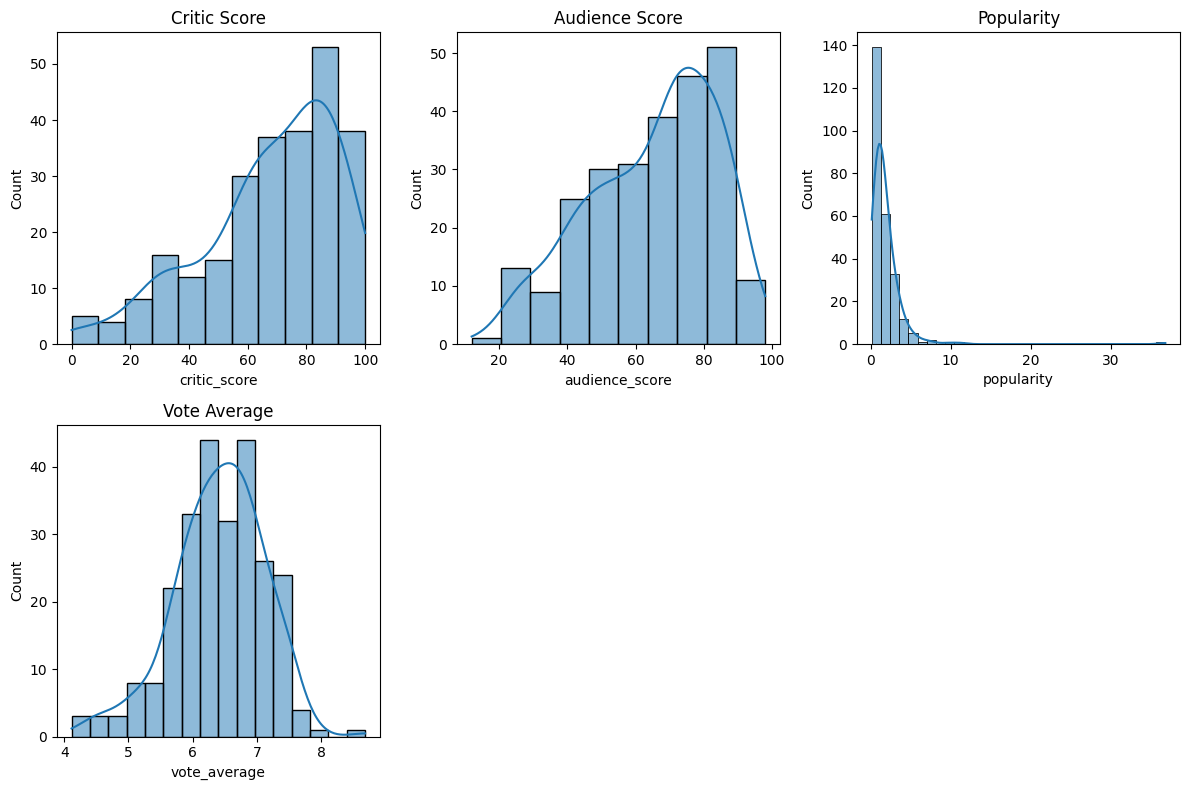

In [ ]:
# Distributions of Variables 

vars = ["critic_score", "audience_score", "popularity", "vote_average"]

plt.figure(figsize=(12, 8))

for i, var in enumerate(vars, 1):
    plt.subplot(2, 3, i)
    sns.histplot(merged_df[var], kde=True)
    plt.title(var.replace('_', ' ').title())

plt.tight_layout()
plt.savefig("figures/distributions.png", dpi=300, bbox_inches="tight")
plt.show()

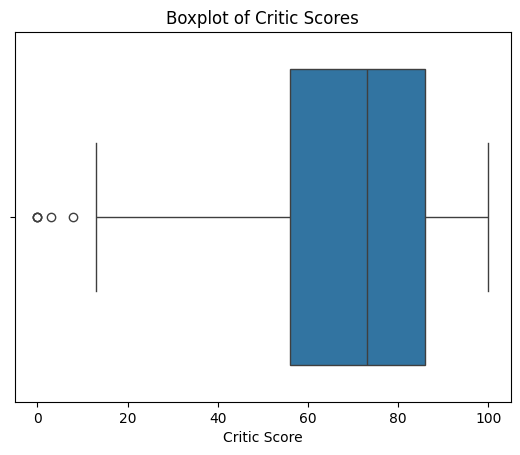

In [ ]:
# box plots to note outliers

plt.figure()
sns.boxplot(x=merged_df["critic_score"])
plt.title("Boxplot of Critic Scores")
plt.xlabel("Critic Score")
plt.savefig("figures/critic_score_box_plots.png", dpi=300, bbox_inches="tight")
plt.show()

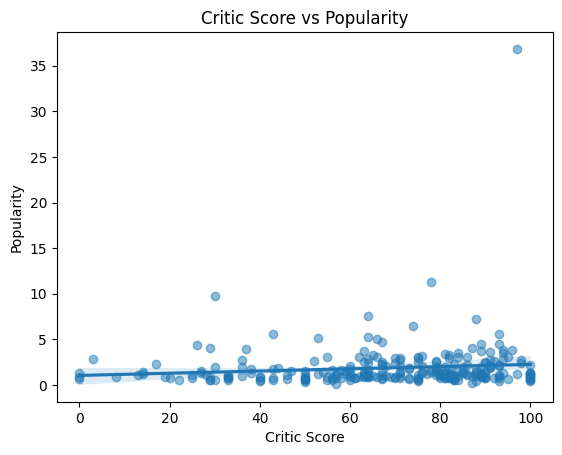

In [ ]:
# critic score vs popularity scatter plt

plt.figure()
sns.regplot(x="critic_score", y="popularity", data=merged_df, scatter_kws={"alpha":0.5})
plt.title("Critic Score vs Popularity")
plt.xlabel("Critic Score")
plt.ylabel("Popularity")
plt.savefig("figures/critic_score_popularity_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

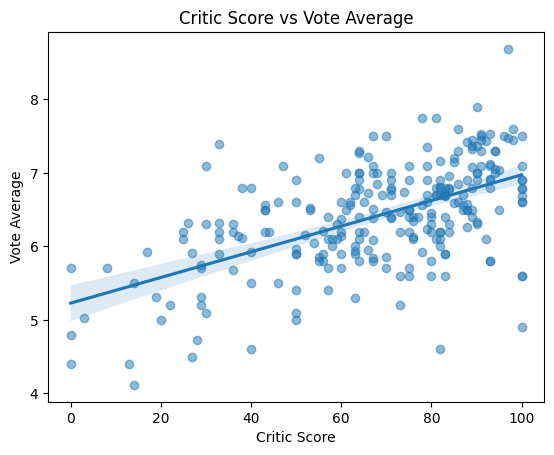

In [ ]:
# critic score vs vote average
plt.figure()
sns.regplot(x="critic_score", y="vote_average", data=merged_df, scatter_kws={"alpha":0.5})
plt.title("Critic Score vs Vote Average")
plt.xlabel("Critic Score")
plt.ylabel("Vote Average")
plt.savefig("figures/critic_score_vote_avg_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

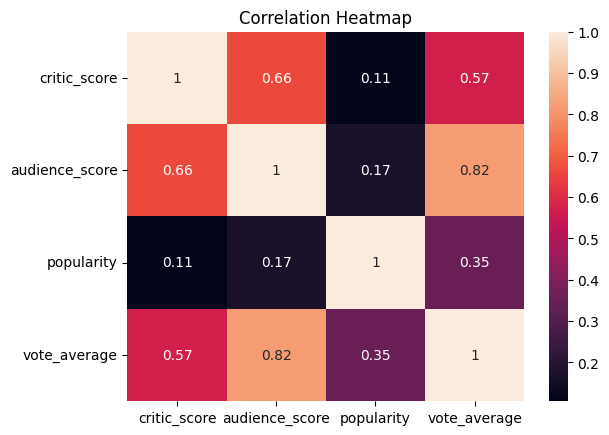

In [ ]:
#heat map

corr = merged_df[[
    "critic_score", "audience_score",
    "popularity", "vote_average"
]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()